In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [3]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [4]:
df.drop(['day', 'month', 'year'],axis=1,inplace=True)

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df['Classes'] = df['Classes'].str.strip() # strpping the white spaces

In [7]:
df['Classes'].unique()

<ArrowStringArray>
['not fire', 'fire']
Length: 2, dtype: str

In [8]:
df['Classes'] = np.where(df['Classes']=='not fire',0,1)
# np.where(df['Classes'].str.contains('not fire'),0,1) -> another way to do without stripping the whitespaces

In [9]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [10]:
X = df.drop('FWI',axis=1)
y = df['FWI']

In [11]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [12]:
## Train Test Split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [14]:
## Feature Selection Based on correlation

X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


What is multicollinearity?

It means two or more input features are strongly correlated (they carry almost the same information). Example: DMC and BUI might move together.

Why it matters

Linear models (linear regression, logistic regression) get unstable coefficients.
Feature importance becomes unreliable.
Models can overfit and become harder to interpret.

<Axes: >

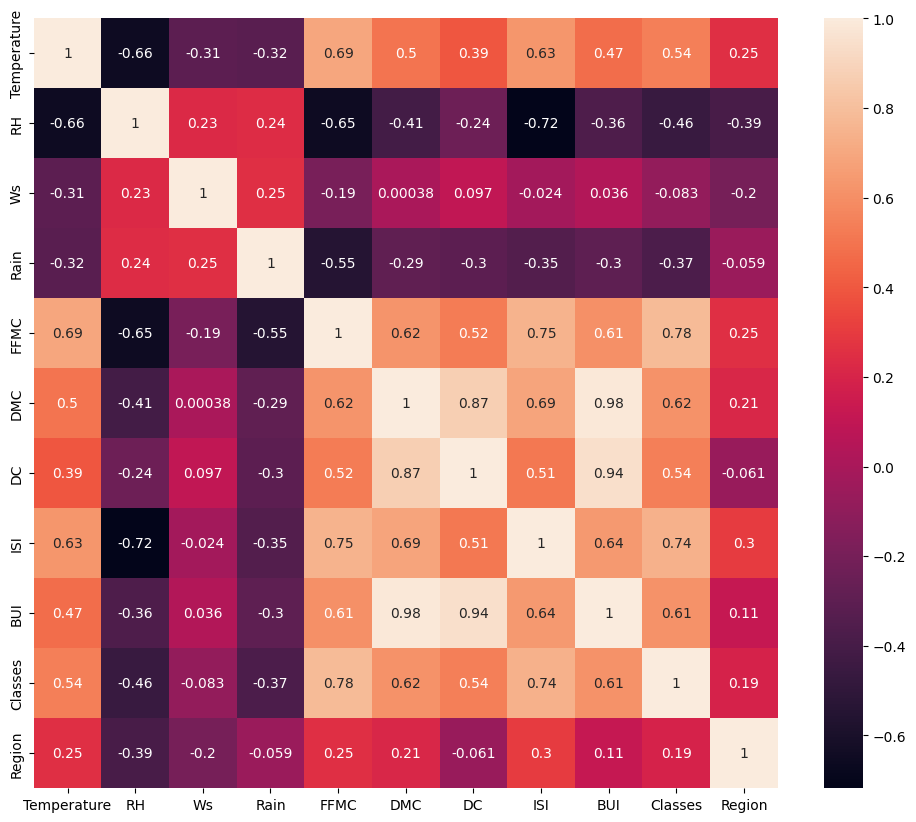

In [15]:
## Check for multicollinearity

plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(),annot=True)

In [16]:
def correlation(dataset,threshold):
    col_corr = set()                 # store columns to drop
    corr_matrix = dataset.corr()     # compute correlation matrix
    for i in range(len(corr_matrix.columns)):      # loop columns
        for j in range(i):                          # only lower triangle
            if abs(corr_matrix.iloc[i,j]) > threshold:  # strong correlation
                colname = corr_matrix.columns[i]
                col_corr.add(colname)              # mark column for removal
    return col_corr


What the above code does ? 

Build the correlation matrix.
Check each pair of features.
If correlation is above the threshold (e.g., 0.75), mark one of them to remove.
It returns a set of column names that are highly correlated with something else and could be dropped to reduce redundancy.

In [17]:
# Usually threshold is set by domain expert

corr_features = correlation(X_train,0.85)

In [18]:
## Drop Features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [19]:
X_train.shape,X_test.shape

((182, 9), (61, 9))

In [20]:
## Feature Scaling or Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

#### Box plot to understand the effect of Standard scaler

Text(0.5, 1.0, 'X_train After Scaling')

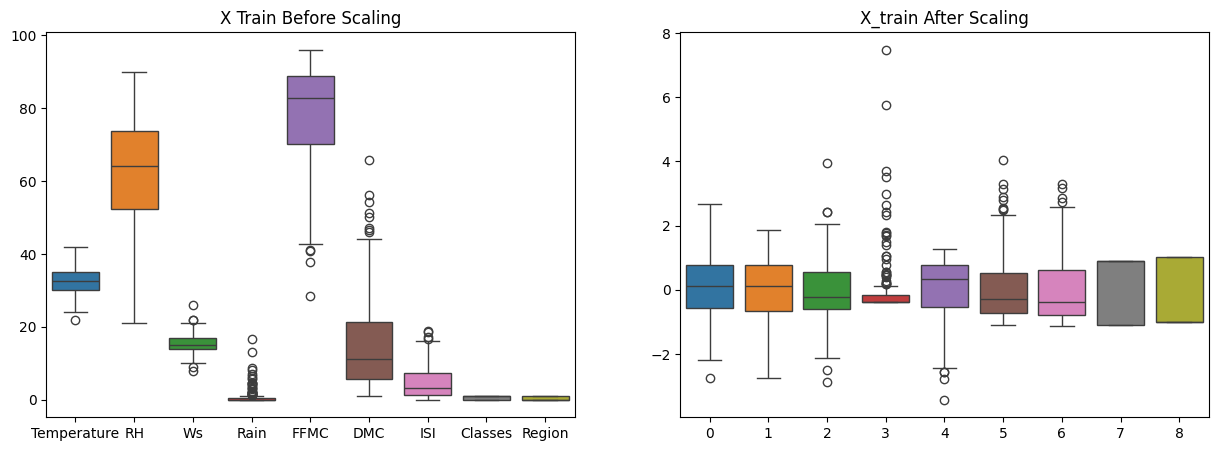

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=X_train, ax=axes[0])
axes[0].set_title('X Train Before Scaling')

sns.boxplot(data=X_train_scaled, ax=axes[1])
axes[1].set_title('X_train After Scaling')

From the box plots:

Before scaling: features have very different ranges and spreads (some are huge, some tiny). This can bias distance‑based or regularized models.
After scaling: distributions are centered around 0 with similar spread, so features are on a comparable scale.
Outliers still exist: scaling doesn’t remove them; it only rescales the data



Why it’s needed:


Distance‑based models (KNN, K‑means, SVM) depend on scale.
Gradient‑based models converge faster and more stably.
Regularization (Ridge/Lasso) assumes features are on similar scales, otherwise large‑scale features dominate the penalty.
Interpretability: coefficients become more comparable.
So scaling isn’t for removing outliers — it’s for fairness and stability in learning

## Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
regression = LinearRegression()


In [25]:
regression.fit(X_train_scaled,y_train)
y_pred = regression.predict(X_test_scaled)


In [26]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("Score: ",score)

MSE: 0.6742766873791607
MAE: 0.5468236465249986
Score:  0.9847657384266951


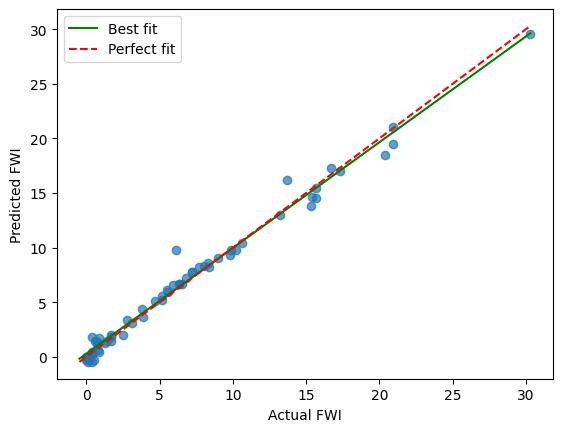

In [27]:
plt.scatter(y_test, y_pred, alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot([min_val, max_val], [m * min_val + b, m * max_val + b], "g-", label="Best fit")
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect fit")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.legend()



- `plt.scatter(...)` plots **Actual vs Predicted** points.  
- `min_val` / `max_val` set the plot range so both lines cover the same span.  
- `m, b = np.polyfit(...)` finds the **best‑fit straight line** through your scatter (least‑squares).  
- `plt.plot(... "g-")` draws that **best‑fit line** (green).  
- `plt.plot(... "r--")` draws the **perfect‑fit line** $y=x$ (red dashed).  
- Labels + legend make it readable.

So you get:
- **Green line** = what your model’s predictions look like on average.  
- **Red line** = ideal predictions.  
The closer green is to red, the better the model.

#### Lasso Regression

In [28]:
from sklearn.linear_model import Lasso
lasso = Lasso()


In [29]:
lasso.fit(X_train_scaled,y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [30]:

y_pred = lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("Score: ",score)

MSE: 2.248345891897476
MAE: 1.1331759949144087
Score:  0.9492020263112388


#### Ridge Regression

In [31]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("Score: ",score)

MSE: 0.6949198918152074
MAE: 0.5642305340105692
Score:  0.9842993364555513


### Elastic Net Regression

In [32]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
elastic = ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred = elastic.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("Score: ",score)

MSE: 5.517251101025223
MAE: 1.8822353634895999
Score:  0.8753460589519703


### Hyperparameter Tuning using lasso cv

In [33]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [34]:
lassocv.alpha_

np.float64(0.06582808719529475)

In [35]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [36]:
lassocv.mse_path_

array([[54.04680834, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139504, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

## Cross-validation model comparison

In [37]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=("neg_mean_squared_error", "neg_mean_absolute_error", "r2"),
        return_train_score=False,
    )
    rmse = np.sqrt(-scores["test_neg_mean_squared_error"])
    mae = -scores["test_neg_mean_absolute_error"]
    cv_results.append({
        "model": name,
        "rmse_mean": rmse.mean(),
        "rmse_std": rmse.std(),
        "mae_mean": mae.mean(),
        "r2_mean": scores["test_r2"].mean(),
    })

cv_df = pd.DataFrame(cv_results).sort_values("rmse_mean")
cv_df

,model,rmse_mean,rmse_std,mae_mean,r2_mean
2,Lasso,1.322219,0.582633,0.772049,0.964737
0,Linear,1.325723,0.588046,0.771872,0.964441
3,ElasticNet,1.329561,0.565769,0.787819,0.964662
1,Ridge,1.333469,0.559609,0.794664,0.964564


**Note:** This compares Linear, Ridge, Lasso, and ElasticNet using 5-fold CV with scaling inside a pipeline. Lower `rmse_mean` is better, and `rmse_std` shows how stable the model is across folds.

## Best model on test set

In [38]:
best_model_name = cv_df.iloc[0]["model"]
best_model = models[best_model_name]

best_pipeline = Pipeline([("scaler", StandardScaler()), ("model", best_model)])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best model: {best_model_name}")
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

Best model: Lasso
MSE: 0.6855739655536462
MAE: 0.5546306860778376
R2: 0.9845104935190809


**Note:** This fits the best CV model on the full training set and evaluates on the held-out test set for an unbiased performance estimate.

## Residual analysis

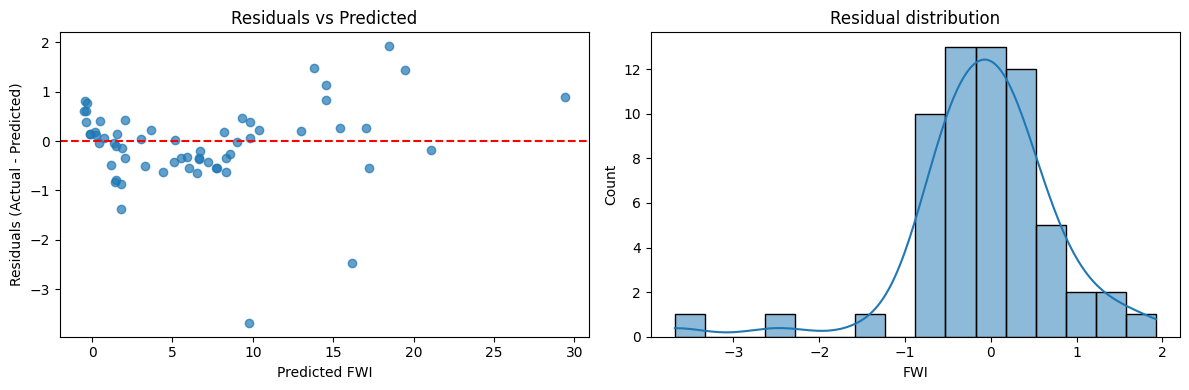

In [39]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted FWI")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")
plt.tight_layout()

**Note:** Residuals are $y_{true} - y_{pred}$. Example: if actual FWI = 30 and predicted = 26, residual = +4 (underprediction). If predicted = 33, residual = -3 (overprediction). A random scatter around 0 is good; patterns usually mean the model is missing structure.

## Feature importance (linear coefficients)

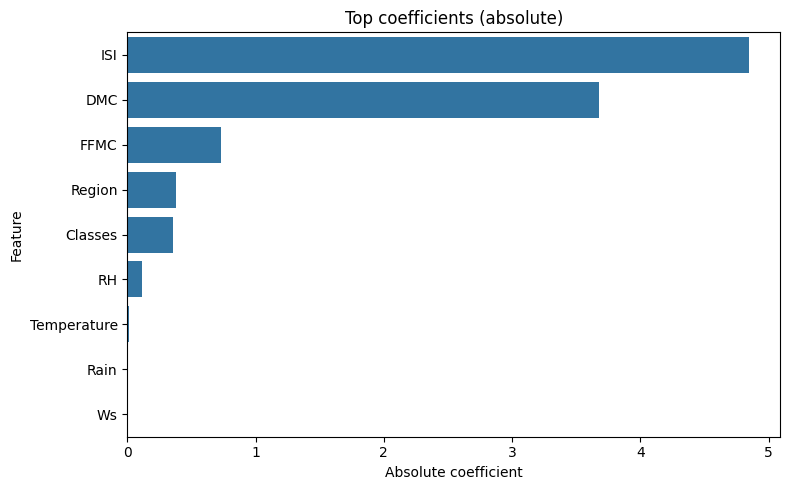

In [40]:
coefs = best_pipeline.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": coefs,
})
coef_df["abs_coeff"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coeff", ascending=False)

coef_df

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df.head(10), x="abs_coeff", y="feature")
plt.title("Top coefficients (absolute)")
plt.xlabel("Absolute coefficient")
plt.ylabel("Feature")
plt.tight_layout()

**Note:** In a linear model $y_{pred} = 2.5 * Temperature - 1.0 * Rain + 10$, the coefficient 2.5 means a 1-unit increase in Temperature raises the prediction by 2.5. The -1.0 means a 1-unit increase in Rain lowers the prediction by 1.0. With scaled features, coefficient magnitudes are comparable.

### From-scratch: ridge regression closed-form solution

`sklearn`'s `Ridge` above solves the penalized least-squares problem internally.
Here we implement the closed-form solution
$\hat\beta = (X^TX + \lambda I)^{-1}X^Ty$ directly in NumPy on the same scaled
training data (`X_train_scaled`, `y_train`), and check it agrees with `sklearn`
at the same `alpha`.

In [41]:
def ridge_closed_form(X, y, lam):
    """Closed-form ridge: theta = (X^T X + lambda * I)^-1 X^T y."""
    n_features = X.shape[1]
    I = np.eye(n_features)
    return np.linalg.inv(X.T @ X + lam * I) @ X.T @ y

theta_manual = ridge_closed_form(X_train_scaled, y_train.values, lam=1.0)
print("From-scratch ridge coefficients (alpha=1.0):", theta_manual)
print("sklearn Ridge(alpha=1.0) coefficients:      ", ridge.coef_)
print("Match within tolerance:", np.allclose(theta_manual, ridge.coef_, atol=1e-2))

From-scratch ridge coefficients (alpha=1.0): [-0.02692577 -0.20519212  0.02554428 -0.04069202 -0.78583006  3.68286744
  4.74488835  0.43423672 -0.38466214]
sklearn Ridge(alpha=1.0) coefficients:       [-0.02692577 -0.20519212  0.02554428 -0.04069202 -0.78583006  3.68286744
  4.74488835  0.43423672 -0.38466214]
Match within tolerance: True


### Experiment: coefficient path (coefficients vs lambda)

**Hypothesis (stated before running):** as $\lambda$ increases, ridge coefficients
should shrink toward zero monotonically but never hit exact zero. Lasso, run over
the same $\lambda$ grid for comparison, should hit exact zeros at moderate
$\lambda$ (dropping features entirely) well before ridge coefficients get
anywhere near zero — the geometric difference between the L2 ball (round,
shrinks smoothly) and the L1 ball (pointed, hits axes) discussed in
`notes.md`.

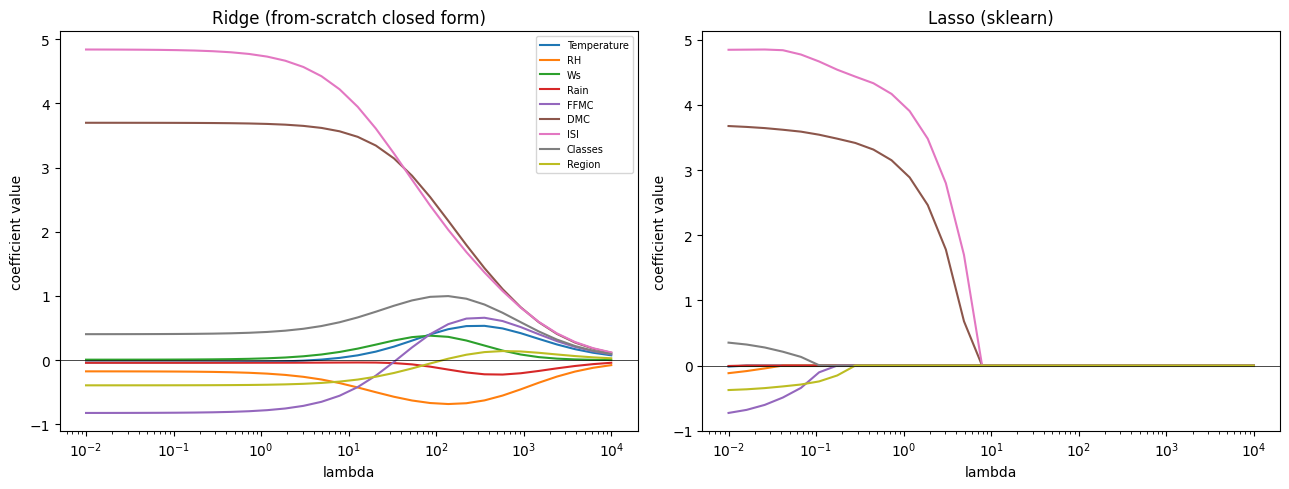

Near-zero ridge coefficients across the whole grid: 0
Near-zero lasso coefficients across the whole grid: 216


In [42]:
lambdas = np.logspace(-2, 4, 30)

ridge_paths = np.array([
    ridge_closed_form(X_train_scaled, y_train.values, lam) for lam in lambdas
])

from sklearn.linear_model import Lasso as _Lasso
lasso_paths = []
for lam in lambdas:
    m = _Lasso(alpha=lam, max_iter=20000)
    m.fit(X_train_scaled, y_train)
    lasso_paths.append(m.coef_)
lasso_paths = np.array(lasso_paths)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, col in enumerate(X_train.columns):
    axes[0].plot(lambdas, ridge_paths[:, i], label=col)
    axes[1].plot(lambdas, lasso_paths[:, i], label=col)

for ax, title in zip(axes, ["Ridge (from-scratch closed form)", "Lasso (sklearn)"]):
    ax.set_xscale("log")
    ax.set_xlabel("lambda")
    ax.set_ylabel("coefficient value")
    ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.5)
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

n_zero_ridge = int((np.abs(ridge_paths) < 1e-8).sum())
n_zero_lasso = int((np.abs(lasso_paths) < 1e-8).sum())
print("Near-zero ridge coefficients across the whole grid:", n_zero_ridge)
print("Near-zero lasso coefficients across the whole grid:", n_zero_lasso)

**Actual result:** see the printed counts and the two coefficient-path plots
above for this dataset's concrete numbers — they are the source of truth.

**Interpretation:** ridge coefficients should trace smooth curves that approach
(but do not touch) zero as $\lambda$ grows; lasso coefficients should visibly
flatten to exactly zero for several features once $\lambda$ passes some
threshold, well before ridge's coefficients are anywhere near zero at the same
$\lambda$. That gap is the sparsity difference predicted by the L1-vs-L2
geometry in `notes.md`.

**Limitations:** this uses one train/test split and one correlated-feature
structure (this dataset's engineered forest-fire indices, some of which were
already dropped above for correlation > 0.85); a different feature set or
correlation structure changes exactly which coefficients zero out and at which
$\lambda$, though the qualitative ridge-vs-lasso shrinkage pattern is
general.